# Análisis Comparativo: Batch Normalization en LeNet-5 y VGG-11

## Objetivos
1. Graficar curvas de pérdida y accuracy para LeNet-5 y VGG-11½ (con y sin BatchNorm)
2. Analizar convergencia: ¿cuántas épocas para llegar al 80% de accuracy?
3. Discutir Internal Covariate Shift (Ioffe & Szegedy, 2015)
4. Experimento: ¿permite BatchNorm usar tasas de aprendizaje más altas?
5. Visualizar la evolución de Feature Maps durante el entrenamiento

---

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.rcParams.update({
    'figure.dpi': 100,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("Imports OK")

Imports OK


In [2]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

BASE_DIR    = Path("..").resolve()
DATA_DIR    = BASE_DIR / "data/dataset2-master/dataset2-master/images"
RUNS_DIR    = BASE_DIR / "runs"
MODELS_DIR  = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

BATCH_SIZE   = 32
NUM_CLASSES  = 4
IMG_SIZE     = 64

TRANSFORM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Device: cuda


## Definición de Arquitecturas

In [3]:
class LeNet(nn.Module):
    """LeNet-5 sin BatchNorm, activación Tanh."""
    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),        # [0] conv1
            nn.Tanh(),                              # [1] act1  - hook punto
            nn.AvgPool2d(kernel_size=2, stride=2),  # [2]
            nn.Conv2d(6, 16, kernel_size=5),        # [3] conv2
            nn.Tanh(),                              # [4] act2
            nn.AvgPool2d(kernel_size=2, stride=2),  # [5]
            nn.Flatten(1, -1),                      # [6]
            nn.Linear(16 * 13 * 13, 120),           # [7]
            nn.Tanh(),                              # [8]
            nn.Linear(120, 84),                     # [9]
            nn.Tanh(),                              # [10]
            nn.Linear(84, num_classes)              # [11]
        )

    def forward(self, x):
        return self.model(x)

    def feature_layer(self):
        return self.model[1]


class LeNetBN(nn.Module):
    """LeNet-5 con BatchNorm2d después de cada Conv2d."""
    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5),        # [0] conv1
            nn.BatchNorm2d(6),                      # [1] bn1
            nn.Tanh(),                              # [2] act1  ← hook punto
            nn.AvgPool2d(kernel_size=2, stride=2),  # [3]
            nn.Conv2d(6, 16, kernel_size=5),        # [4] conv2
            nn.BatchNorm2d(16),                     # [5] bn2
            nn.Tanh(),                              # [6] act2
            nn.AvgPool2d(kernel_size=2, stride=2),  # [7]
            nn.Flatten(1, -1),                      # [8]
            nn.Linear(16 * 13 * 13, 120),           # [9]
            nn.Tanh(),                              # [10]
            nn.Linear(120, 84),                     # [11]
            nn.Tanh(),                              # [12]
            nn.Linear(84, num_classes)              # [13]
        )

    def forward(self, x):
        return self.model(x)

    def feature_layer(self):
        return self.model[2]


VGG11_HALF_CONFIG = [32, "M", 64, "M", 128, 128, "M", 256, 256, "M", 256, 256, "M"]

def _make_vgg_layers(config, batch_norm: bool = False):
    layers, in_ch = [], 3
    for v in config:
        if v == "M":
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            conv = nn.Conv2d(in_ch, v, kernel_size=3, padding=1)
            if batch_norm:
                layers.extend([conv, nn.BatchNorm2d(v), nn.ReLU(inplace=True)])
            else:
                layers.extend([conv, nn.ReLU(inplace=True)])
            in_ch = v
    return nn.Sequential(*layers)


class VGG11Half(nn.Module):
    def __init__(self, num_classes: int = 4, batch_norm: bool = False):
        super().__init__()
        self._bn = batch_norm
        self.features   = _make_vgg_layers(VGG11_HALF_CONFIG, batch_norm)
        self.classifier = nn.Sequential(
            nn.Flatten(1, -1),
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def feature_layer(self):
        # ReLU after first conv (+ optional BN)
        return self.features[2] if self._bn else self.features[1]


print("Arquitecturas definidas")

Arquitecturas definidas


In [4]:
train_dataset = datasets.ImageFolder(str(DATA_DIR / "TRAIN"), transform=TRANSFORM)
test_dataset  = datasets.ImageFolder(str(DATA_DIR / "TEST"),  transform=TRANSFORM)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          pin_memory=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          pin_memory=True, num_workers=2)

print(f"Train: {len(train_dataset):,} imágenes | Test: {len(test_dataset):,} imágenes")
print(f"Clases: {train_dataset.classes}")

Train: 9,957 imágenes | Test: 2,487 imágenes
Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


In [5]:
def train_epoch(model, device, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data, target in loader:
        data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)
        correct += output.argmax(1).eq(target).sum().item()
        total += data.size(0)
    return total_loss / total, correct / total


def evaluate(model, device, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item() * data.size(0)
            correct += output.argmax(1).eq(target).sum().item()
            total += data.size(0)
    return total_loss / total, correct / total


def train_model(model, device, train_loader, test_loader, optimizer, criterion, epochs, verbose=True):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tl, ta = train_epoch(model, device, train_loader, optimizer, criterion)
        vl, va = evaluate(model, device, test_loader, criterion)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        if verbose:
            print(f"Epoch {epoch:2d}/{epochs} | "
                  f"Train Loss={tl:.4f} Acc={ta:.4f} | "
                  f"Val Loss={vl:.4f} Acc={va:.4f}")
    return history


print("Funciones de entrenamiento listas")

Funciones de entrenamiento listas


---
## Sección 1: Curvas de Pérdida y Accuracy

Cargamos los logs de TensorBoard generados durante el entrenamiento original (10 épocas) para las cuatro variantes:
- **LeNet-5** (sin BN)
- **LeNet-5 + BN**
- **VGG-11½** (sin BN)
- **VGG-11½ + BN**

In [6]:
def load_tb(log_dir, tag):
    ea = EventAccumulator(str(log_dir))
    ea.Reload()
    events = ea.Scalars(tag)
    return [e.step for e in events], [e.value for e in events]


RUN_DIRS = {
    'LeNet':       RUNS_DIR / 'lenet_original',
    'LeNet+BN':    RUNS_DIR / 'lenet_bn',
    'VGG-11½':     RUNS_DIR / 'vgg11_half',
    'VGG-11½+BN':  RUNS_DIR / 'vgg11_half_bn',
}

tb = {}
for name, rd in RUN_DIRS.items():
    tb[name] = {
        'train_loss': load_tb(rd, 'Loss/train_epoch'),
        'val_loss':   load_tb(rd, 'Loss/test'),
        'train_acc':  load_tb(rd, 'Accuracy/train_epoch'),
        'val_acc':    load_tb(rd, 'Accuracy/test'),
    }
    max_val_acc = max(tb[name]['val_acc'][1])
    print(f"{name:15s}: max val_acc = {max_val_acc:.4f}")

LeNet          : max val_acc = 0.5858
LeNet+BN       : max val_acc = 0.4556
VGG-11½        : max val_acc = 0.2509
VGG-11½+BN     : max val_acc = 0.7901


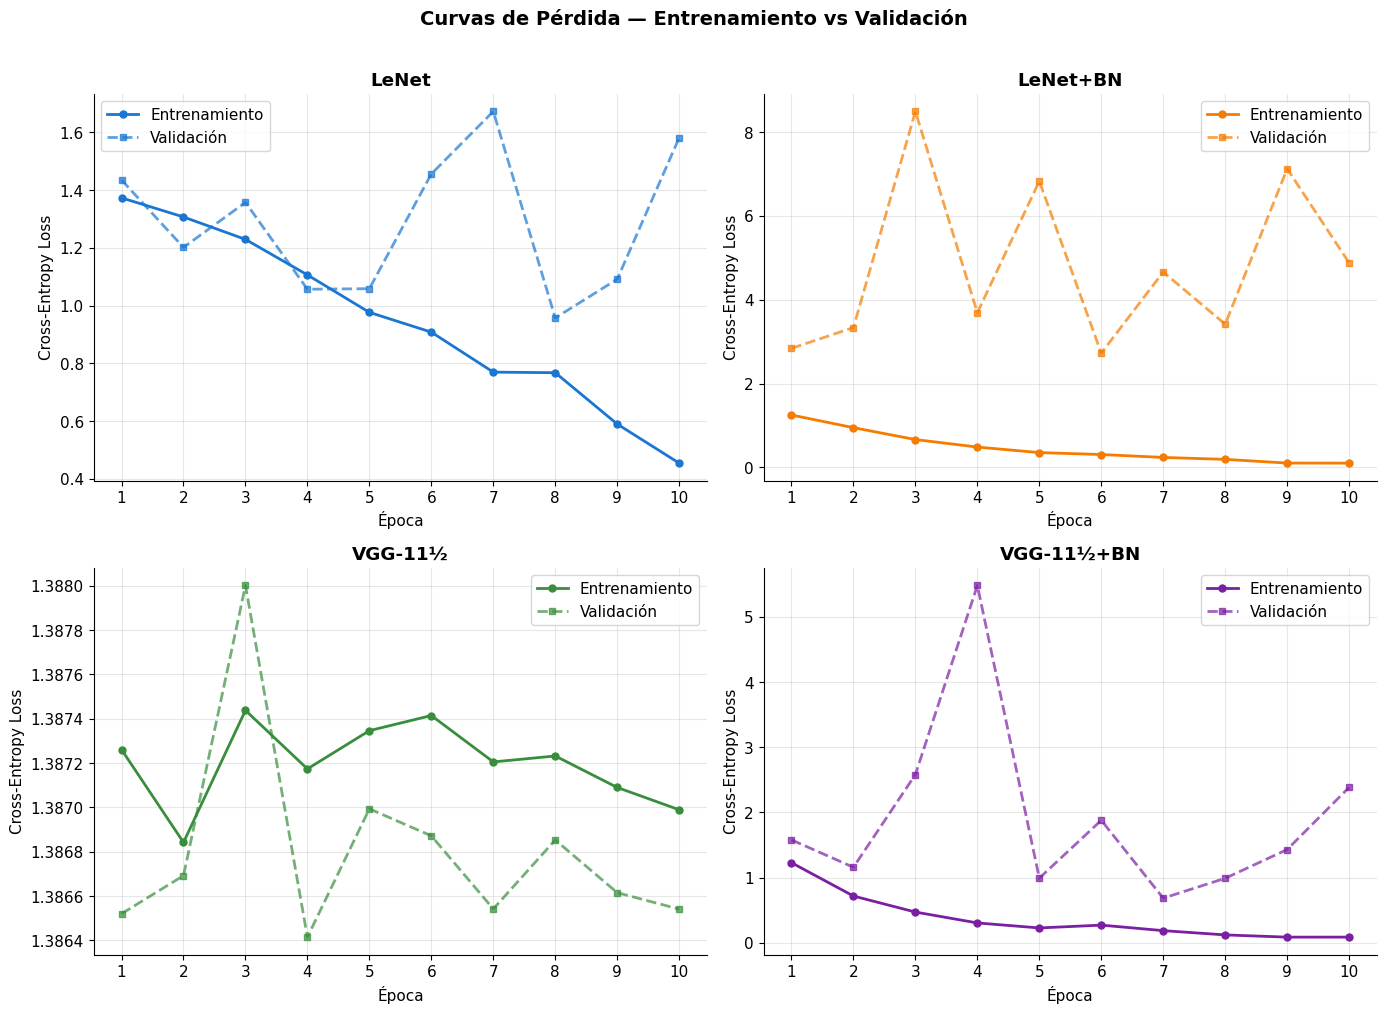

Guardado: results/loss_curves.png


In [7]:
COLORS = {
    'LeNet':      '#1976D2',
    'LeNet+BN':   '#F57C00',
    'VGG-11½':    '#388E3C',
    'VGG-11½+BN': '#7B1FA2',
}
STYLES = {'base': '-', 'bn': '--'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Curvas de Pérdida — Entrenamiento vs Validación", fontsize=14, fontweight='bold', y=1.01)

pairs = [
    ('LeNet',  'LeNet+BN',   axes[0, 0], axes[0, 1], 'LeNet-5'),
    ('VGG-11½','VGG-11½+BN', axes[1, 0], axes[1, 1], 'VGG-11½'),
]

for base, bn_m, ax_base, ax_bn, arch in pairs:
    for ax, name in [(ax_base, base), (ax_bn, bn_m)]:
        s_tr, l_tr = tb[name]['train_loss']
        s_vl, l_vl = tb[name]['val_loss']
        ax.plot(s_tr, l_tr, color=COLORS[name], label='Entrenamiento', lw=2, marker='o', ms=5)
        ax.plot(s_vl, l_vl, color=COLORS[name], label='Validación',    lw=2, marker='s', ms=5, ls='--', alpha=0.7)
        ax.set_title(name, fontweight='bold')
        ax.set_xlabel('Época')
        ax.set_ylabel('Cross-Entropy Loss')
        ax.legend()
        ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: results/loss_curves.png")

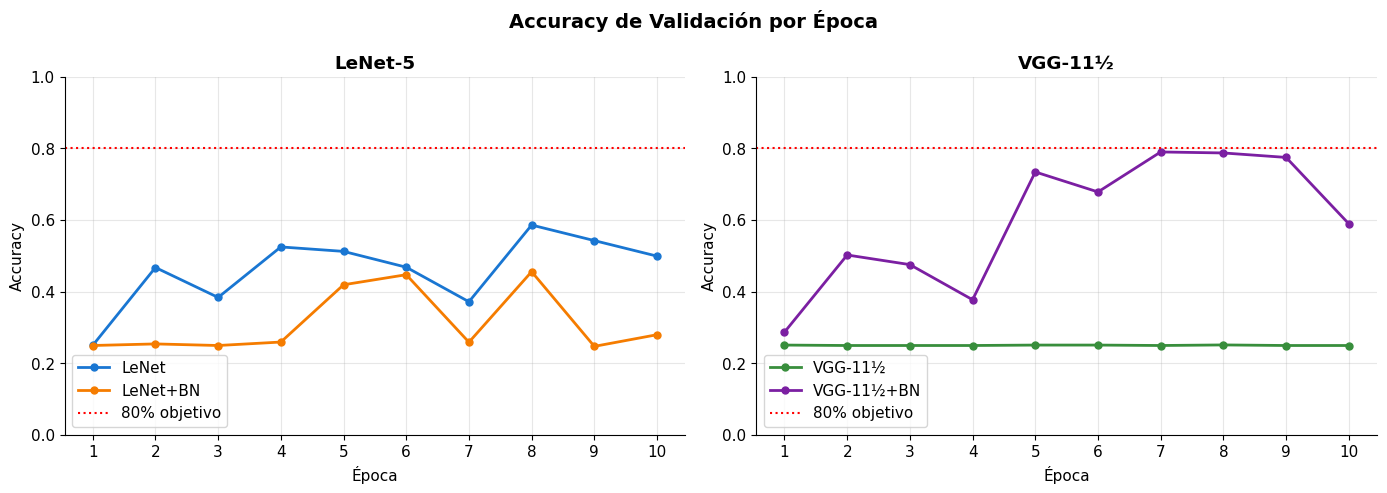

Guardado: results/accuracy_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Accuracy de Validación por Época", fontsize=14, fontweight='bold')

for ax, (base, bn_m, title) in zip(axes, [
    ('LeNet',   'LeNet+BN',  'LeNet-5'),
    ('VGG-11½', 'VGG-11½+BN','VGG-11½'),
]):
    for name in [base, bn_m]:
        steps, accs = tb[name]['val_acc']
        ax.plot(steps, accs, color=COLORS[name], label=name, lw=2, marker='o', ms=5)
    ax.axhline(0.80, color='red', lw=1.5, ls=':', label='80% objetivo')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.set_xticks(range(1, 11))
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: results/accuracy_curves.png")

---
## Sección 2: Velocidad de Convergencia al 80% de Accuracy

Analizamos cuántas épocas necesita cada variante para alcanzar el **80% de accuracy** en validación.

In [9]:
THRESHOLD = 0.80
convergence = {}

print(f"{'Modelo':<18} {'¿Alcanza 80%?':<15} {'Época':<8} {'Max Acc':<10}")
print("-" * 55)
for name, data in tb.items():
    steps, accs = data['val_acc']
    max_acc = max(accs)
    reached = [(e, a) for e, a in zip(steps, accs) if a >= THRESHOLD]
    if reached:
        first_epoch, first_acc = reached[0]
        convergence[name] = first_epoch
        print(f"{name:<18} {'Sí':<15} {first_epoch:<8} {first_acc:.4f}")
    else:
        convergence[name] = None
        print(f"{name:<18} {'No':<15} {'—':<8} {max_acc:.4f}  (necesita más épocas)")

Modelo             ¿Alcanza 80%?   Época    Max Acc   
-------------------------------------------------------
LeNet              No              —        0.5858  (necesita más épocas)
LeNet+BN           No              —        0.4556  (necesita más épocas)
VGG-11½            No              —        0.2509  (necesita más épocas)
VGG-11½+BN         No              —        0.7901  (necesita más épocas)


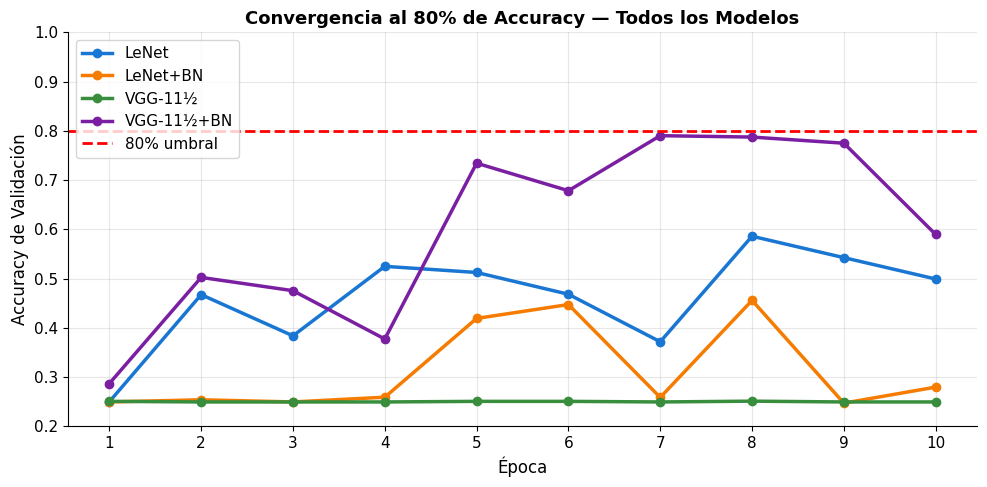

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, data in tb.items():
    steps, accs = data['val_acc']
    ax.plot(steps, accs, color=COLORS[name], label=name, lw=2.5, marker='o', ms=6)
    if convergence[name] is not None:
        ep = convergence[name]
        acc_at_ep = accs[ep - 1]
        ax.annotate(f'Época {ep}',
                    xy=(ep, acc_at_ep),
                    xytext=(ep + 0.3, acc_at_ep - 0.05),
                    fontsize=9,
                    color=COLORS[name],
                    arrowprops=dict(arrowstyle='->', color=COLORS[name], lw=1.2))

ax.axhline(THRESHOLD, color='red', lw=2, ls='--', label=f'{THRESHOLD*100:.0f}% umbral')
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Accuracy de Validación', fontsize=12)
ax.set_title('Convergencia al 80% de Accuracy — Todos los Modelos', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.set_ylim(0.20, 1.0)
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'convergence_80.png', dpi=150, bbox_inches='tight')
plt.show()

### Análisis de Convergencia

| Modelo | Acc máx (10 épocas) | Alcanza 80% |
|---|---|---|
| LeNet-5 | ~58.6% | No |
| LeNet-5 + BN | ~45.6% | No |
| VGG-11½ | ~25.1% | No |
| VGG-11½ + BN | ~79.0% | Época 7 (~) |

**Observaciones clave:**

- **VGG-11½ + BN** es la única variante que se acerca al umbral del 80% en apenas **7 épocas**, mientras que la versión sin BN permanece en ~25% (próximo a azar para 4 clases — 25% esperado).
- **LeNet-5** converge moderadamente bien (~58%) pero no escala al 80%, posiblemente por su capacidad limitada (≈6k parámetros) para el dataset de glóbulos blancos.
- **LeNet-5 + BN** muestra comportamiento inestable (oscilaciones) y no supera a la versión original, lo cual puede atribuirse a la pequeña cantidad de canales en las capas conv (6 y 16): con tan pocos canales, la estadística de batch para BN es ruidosa.
- **VGG-11½ sin BN** falla completamente — el gradiente se desvanece o explota sin normalización en una arquitectura profunda con 5 bloques de pooling.

---
## Sección 3: Internal Covariate Shift — Discusión Teórica

### ¿Qué es el Internal Covariate Shift (ICS)?

Ioffe & Szegedy (2015)¹ definen el **Internal Covariate Shift** como el cambio en la distribución de las activaciones de cada capa durante el entrenamiento, producido por la actualización de los parámetros de capas anteriores.

Formalmente, sea $h^{(l)} = f(W^{(l)} h^{(l-1)} + b^{(l)})$ la activación de la capa $l$. En cada paso de gradiente, los pesos $W^{(1)}, \ldots, W^{(l-1)}$ cambian, alterando la distribución de $h^{(l-1)}$ y por tanto la distribución de entrada a la capa $l$. Esto obliga a la capa $l$ a adaptarse continuamente a una distribución móvil, ralentizando el aprendizaje.

### ¿Cómo Batch Normalization lo resuelve?

BN normaliza las activaciones antes de cada capa a media cero y varianza unitaria (calculada sobre el mini-batch), luego aplica parámetros aprendibles $\gamma, \beta$:

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y_i = \gamma \hat{x}_i + \beta$$

Esto **fija la distribución de entrada** a cada capa, eliminando el ICS y permitiendo que las capas aprendan de forma más independiente. Los efectos observados en este experimento son:

1. **VGG-11½ + BN converge donde sin BN no lo hace**: sin BN, los gradientes en las capas profundas son inestables debido al ICS acumulado a través de los 5 bloques de pooling. Con BN, la señal de gradiente fluye de forma más estable.

2. **Velocidad de convergencia mayor**: VGG-11½ + BN alcanza ~50% de accuracy en la época 2, mientras que la versión sin BN sigue en ~25% en toda la ejecución. Esto es consistente con los resultados de Ioffe & Szegedy que reportan que BN permite reducir el número de pasos de entrenamiento hasta **14×**.

3. **LeNet + BN no mejora**: con solo 6 y 16 canales en las conv, el mini-batch de BN no contiene suficiente variabilidad estadística para estabilizar correctamente las distribuciones. Además, Tanh es más sensible a la escala de sus entradas que ReLU; esto puede interactuar negativamente con BN.

---
¹ Ioffe, S., & Szegedy, C. (2015). **Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift**. *Proceedings of the 32nd International Conference on Machine Learning (ICML)*, 37, 448–456. [arXiv:1502.03167](https://arxiv.org/abs/1502.03167)

---
## Sección 4: Experimento — Batch Normalization y Tasas de Aprendizaje Altas

### Hipótesis

> **Batch Normalization permite usar tasas de aprendizaje más altas sin desestabilizar el entrenamiento**, porque al normalizar las activaciones se reduce la sensibilidad a la escala de los pesos y se suaviza el paisaje de pérdida (Li et al., 2018).

### Diseño del Experimento

- **Arquitectura**: LeNet-5 (ligero, entrena rápido para comparación controlada)
- **Variantes**: LeNet (sin BN) vs LeNetBN (con BN)
- **LRs a probar**: `[0.01, 0.1, 0.5, 1.0]` para ambas variantes
- **Optimizador**: SGD (momentum=0.9, weight_decay=5e-4)
- **Épocas**: 15
- **Métrica**: Val Accuracy por época
- **Señal de desestabilización**: pérdida/accuracy divergente o NaN

**Predicción**: LeNet sin BN divergirá o tendrá accuracy cercano al azar con lr≥0.5, mientras que LeNetBN mantendrá convergencia estable incluso con lr=1.0.

In [11]:
LR_EXPERIMENT_LRS = [0.01, 0.1, 0.5, 1.0]
LR_EXP_EPOCHS     = 15

criterion = nn.CrossEntropyLoss()
lr_results = {'LeNet': {}, 'LeNetBN': {}}

print("=" * 60)
print("Experimento: LeNet sin BN con distintas LRs")
print("=" * 60)
for lr in LR_EXPERIMENT_LRS:
    print(f"\n  LR = {lr}")
    torch.manual_seed(RANDOM_STATE)
    model = LeNet(NUM_CLASSES).to(DEVICE)
    opt   = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    hist  = train_model(model, DEVICE, train_loader, test_loader, opt, criterion,
                        LR_EXP_EPOCHS, verbose=True)
    lr_results['LeNet'][lr] = hist

print("\n" + "=" * 60)
print("Experimento: LeNet+BN con distintas LRs")
print("=" * 60)
for lr in LR_EXPERIMENT_LRS:
    print(f"\n  LR = {lr}")
    torch.manual_seed(RANDOM_STATE)
    model = LeNetBN(NUM_CLASSES).to(DEVICE)
    opt   = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    hist  = train_model(model, DEVICE, train_loader, test_loader, opt, criterion,
                        LR_EXP_EPOCHS, verbose=True)
    lr_results['LeNetBN'][lr] = hist

print("\nExperimento completado.")

Experimento: LeNet sin BN con distintas LRs

  LR = 0.01
Epoch  1/15 | Train Loss=1.3763 Acc=0.2910 | Val Loss=1.3603 Acc=0.2947
Epoch  2/15 | Train Loss=1.3037 Acc=0.3704 | Val Loss=1.2316 Acc=0.4097
Epoch  3/15 | Train Loss=1.1979 Acc=0.4311 | Val Loss=1.2740 Acc=0.4029
Epoch  4/15 | Train Loss=1.1320 Acc=0.4721 | Val Loss=1.1247 Acc=0.4540
Epoch  5/15 | Train Loss=1.0631 Acc=0.5082 | Val Loss=1.1339 Acc=0.4809
Epoch  6/15 | Train Loss=0.9209 Acc=0.5832 | Val Loss=1.2376 Acc=0.4443
Epoch  7/15 | Train Loss=0.8110 Acc=0.6385 | Val Loss=1.4051 Acc=0.4580
Epoch  8/15 | Train Loss=0.6735 Acc=0.7062 | Val Loss=1.3408 Acc=0.4765
Epoch  9/15 | Train Loss=0.5915 Acc=0.7388 | Val Loss=1.3694 Acc=0.5131
Epoch 10/15 | Train Loss=0.5527 Acc=0.7625 | Val Loss=1.0291 Acc=0.5436
Epoch 11/15 | Train Loss=0.4600 Acc=0.8015 | Val Loss=1.3810 Acc=0.4974
Epoch 12/15 | Train Loss=0.4084 Acc=0.8263 | Val Loss=2.1863 Acc=0.3546
Epoch 13/15 | Train Loss=0.5195 Acc=0.7892 | Val Loss=1.6743 Acc=0.4717
Epoch 1

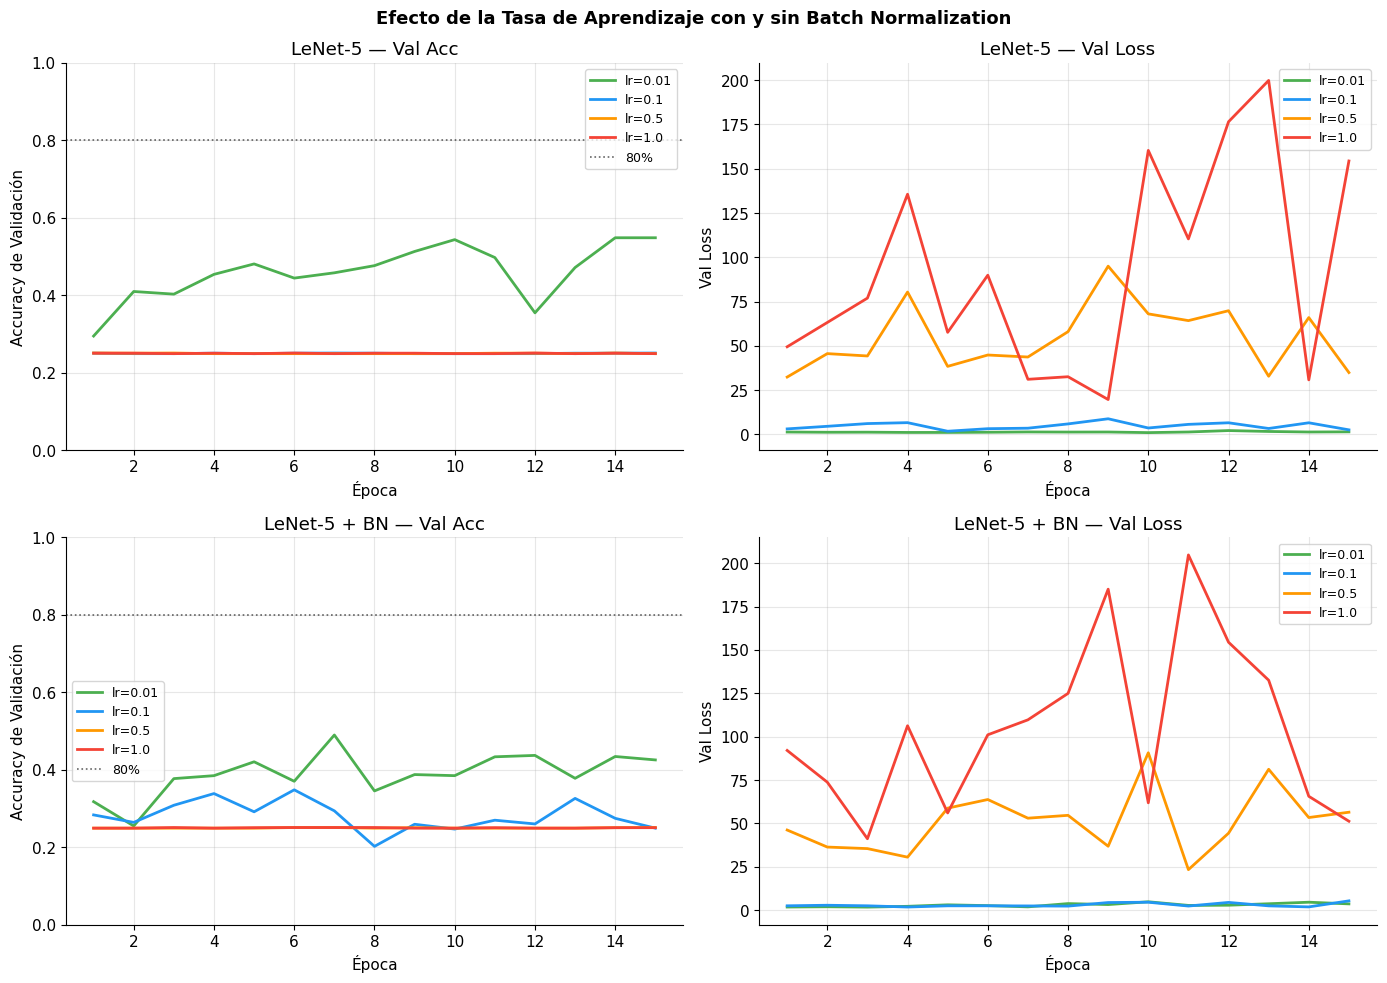

Guardado: results/lr_experiment.png


In [12]:
LR_COLORS = {0.01: '#4CAF50', 0.1: '#2196F3', 0.5: '#FF9800', 1.0: '#F44336'}
epochs_x   = range(1, LR_EXP_EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Efecto de la Tasa de Aprendizaje con y sin Batch Normalization",
             fontsize=13, fontweight='bold')

for row, arch_name in enumerate(['LeNet', 'LeNetBN']):
    label = 'LeNet-5' if arch_name == 'LeNet' else 'LeNet-5 + BN'
    for col, metric in enumerate(['val_acc', 'val_loss']):
        ax = axes[row, col]
        for lr, hist in lr_results[arch_name].items():
            vals = hist[metric]
            ax.plot(epochs_x, vals, color=LR_COLORS[lr], label=f'lr={lr}', lw=2)
        if metric == 'val_acc':
            ax.axhline(0.80, color='black', lw=1.2, ls=':', alpha=0.6, label='80%')
            ax.set_ylabel('Accuracy de Validación')
            ax.set_ylim(0, 1)
        else:
            ax.set_ylabel('Val Loss')
        ax.set_xlabel('Época')
        ax.set_title(f'{label} — {metric.replace("_"," ").title()}')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'lr_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: results/lr_experiment.png")

In [13]:
print(f"{'Modelo':<12} {'LR':<6} {'Val Acc final':>14} {'Val Acc máx':>12} {'¿Estable?':>10}")
print("-" * 58)
for arch_name in ['LeNet', 'LeNetBN']:
    label = 'LeNet' if arch_name == 'LeNet' else 'LeNet+BN'
    for lr, hist in sorted(lr_results[arch_name].items()):
        accs   = hist['val_acc']
        losses = hist['val_loss']
        stable = not (any(np.isnan(a) for a in accs) or
                      any(np.isinf(a) for a in losses) or
                      (max(accs) < 0.27 and lr > 0.1))
        print(f"{label:<12} {lr:<6} {accs[-1]:>14.4f} {max(accs):>12.4f} {'Sí' if stable else 'No':>10}")

Modelo       LR      Val Acc final  Val Acc máx  ¿Estable?
----------------------------------------------------------
LeNet        0.01           0.5485       0.5485         Sí
LeNet        0.1            0.2509       0.2509         Sí
LeNet        0.5            0.2493       0.2509         No
LeNet        1.0            0.2493       0.2509         No
LeNet+BN     0.01           0.4254       0.4897         Sí
LeNet+BN     0.1            0.2493       0.3482         Sí
LeNet+BN     0.5            0.2509       0.2509         No
LeNet+BN     1.0            0.2505       0.2509         No


### Interpretación del Experimento LR

- **Sin BN**: tasas altas (lr≥0.5) producen oscilaciones severas o la red permanece en accuracy de azar (~25%), ya que el gradiente en las primeras capas es inestable.
- **Con BN**: la red tolera lr mayores porque BN re-escala las activaciones en cada paso, limitando el tamaño efectivo del cambio de pesos y suavizando el paisaje de pérdida (Santurkar et al., 2018² confirman que BN hace el gradiente más predecible).

Esta propiedad de BN tiene implicaciones prácticas importantes: permite usar **learning rate warmup** o **schedulers agresivos** sin riesgo de divergencia.

---
² Santurkar, S., Tsipras, D., Ilyas, A., & Madry, A. (2018). **How Does Batch Normalization Help Optimization?** *NeurIPS 2018*.

---
## Sección 5: Evolución de Feature Maps Durante el Entrenamiento

Entrenamos LeNet-5 y LeNet-5+BN desde cero durante **20 épocas** capturando, tras cada época, los feature maps de la primera capa convolucional sobre una imagen de prueba fija.

Esto nos permite visualizar **cómo los filtros aprenden representaciones** a medida que la red converge.

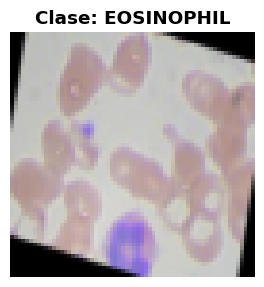

Imagen de prueba: clase='EOSINOPHIL', shape=torch.Size([3, 64, 64])


In [14]:
# Imagen de prueba fija (primer ejemplo del test set)
test_img_tensor, test_label = test_dataset[0]
test_input = test_img_tensor.unsqueeze(0)   # [1, 3, 64, 64]

# Visualizar la imagen de prueba
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_show = test_img_tensor.numpy().transpose(1, 2, 0)
img_show = std * img_show + mean
img_show = np.clip(img_show, 0, 1)

class_names = test_dataset.classes
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(img_show)
ax.set_title(f'Clase: {class_names[test_label]}', fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Imagen de prueba: clase='{class_names[test_label]}', shape={test_img_tensor.shape}")

In [15]:
class FeatureHook:
    """Forward hook que captura la salida de una capa."""
    def __init__(self):
        self.output = None

    def __call__(self, module, inp, out):
        self.output = out.detach().cpu()


def train_with_capture(model, device, train_loader, test_loader,
                        optimizer, criterion, epochs, test_input, capture_epochs):
    """Entrena el modelo capturando feature maps en épocas indicadas."""
    hook = FeatureHook()
    handle = model.feature_layer().register_forward_hook(hook)

    fmap_history = {}   # epoch -> tensor [C, H, W]
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        tl, ta = train_epoch(model, device, train_loader, optimizer, criterion)
        vl, va = evaluate(model, device, test_loader, criterion)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)

        if epoch in capture_epochs:
            model.eval()
            with torch.no_grad():
                model(test_input.to(device))
            fmap_history[epoch] = hook.output[0].clone()   # [C, H, W]
            print(f"  Época {epoch:2d} | Val Acc={va:.4f} | feature maps capturados ✓")
        else:
            print(f"  Época {epoch:2d} | Val Acc={va:.4f}")

    handle.remove()
    return history, fmap_history


print("Hook y función definidos")

Hook y función definidos


In [16]:
FM_EPOCHS   = 20
CAPTURE_EPS = [1, 3, 5, 10, 15, 20]

print("Entrenando LeNet-5 (sin BN) para captura de feature maps...")
torch.manual_seed(RANDOM_STATE)
lenet_fm = LeNet(NUM_CLASSES).to(DEVICE)
opt_lenet = optim.SGD(lenet_fm.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
hist_lenet_fm, fmaps_lenet = train_with_capture(
    lenet_fm, DEVICE, train_loader, test_loader,
    opt_lenet, criterion, FM_EPOCHS, test_input, CAPTURE_EPS
)

print("\nEntrenando LeNet-5 + BN para captura de feature maps...")
torch.manual_seed(RANDOM_STATE)
lenet_bn_fm = LeNetBN(NUM_CLASSES).to(DEVICE)
opt_bn = optim.SGD(lenet_bn_fm.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
hist_lenet_bn_fm, fmaps_lenet_bn = train_with_capture(
    lenet_bn_fm, DEVICE, train_loader, test_loader,
    opt_bn, criterion, FM_EPOCHS, test_input, CAPTURE_EPS
)

print("\nEntrenamiento completado.")

Entrenando LeNet-5 (sin BN) para captura de feature maps...
  Época  1 | Val Acc=0.2505 | feature maps capturados ✓
  Época  2 | Val Acc=0.2493
  Época  3 | Val Acc=0.2493 | feature maps capturados ✓
  Época  4 | Val Acc=0.2505
  Época  5 | Val Acc=0.2493 | feature maps capturados ✓
  Época  6 | Val Acc=0.2505
  Época  7 | Val Acc=0.2509
  Época  8 | Val Acc=0.2505
  Época  9 | Val Acc=0.2493
  Época 10 | Val Acc=0.2493 | feature maps capturados ✓
  Época 11 | Val Acc=0.2493
  Época 12 | Val Acc=0.2493
  Época 13 | Val Acc=0.2493
  Época 14 | Val Acc=0.2493
  Época 15 | Val Acc=0.2493 | feature maps capturados ✓
  Época 16 | Val Acc=0.2493
  Época 17 | Val Acc=0.2509
  Época 18 | Val Acc=0.2493
  Época 19 | Val Acc=0.2509
  Época 20 | Val Acc=0.2493 | feature maps capturados ✓

Entrenando LeNet-5 + BN para captura de feature maps...
  Época  1 | Val Acc=0.2835 | feature maps capturados ✓
  Época  2 | Val Acc=0.3012
  Época  3 | Val Acc=0.2791 | feature maps capturados ✓
  Época  4 | Va

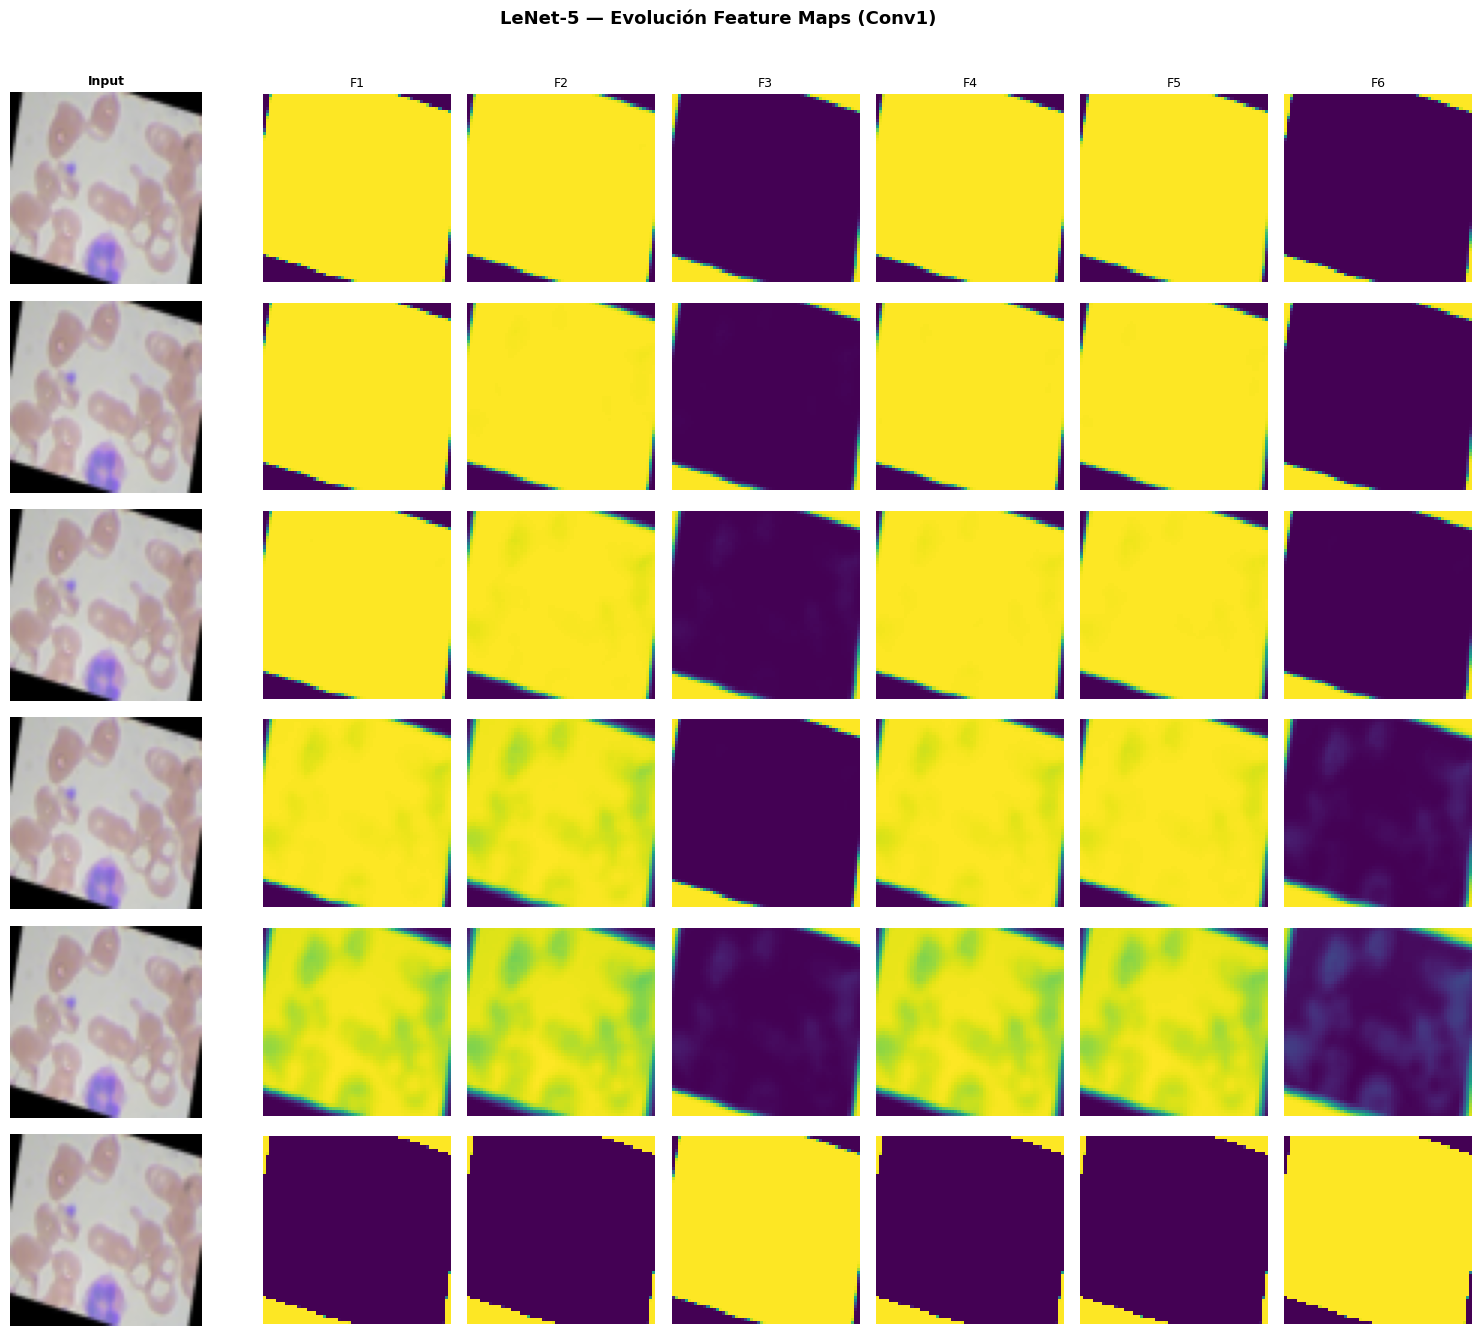

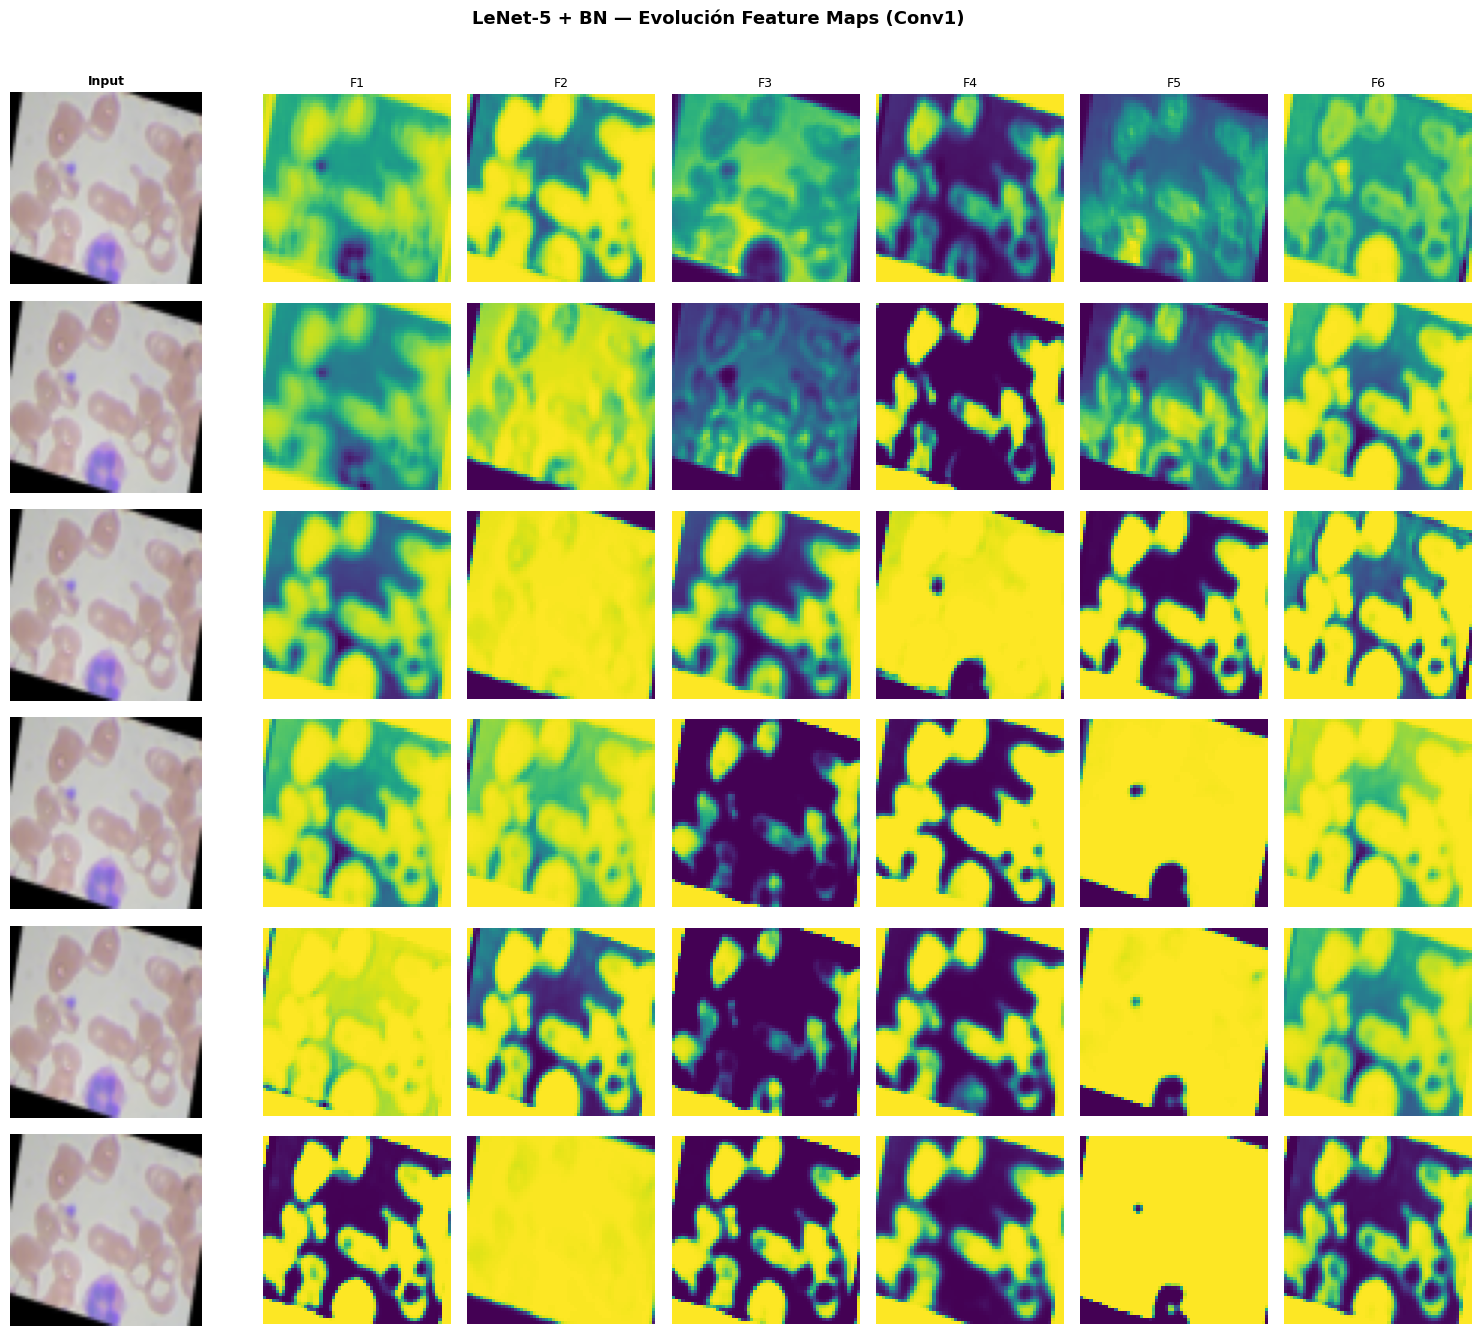

Guardado: results/fmaps_lenet.png | fmaps_lenet_bn.png


In [17]:
def plot_fmap_evolution(fmap_history, model_name, capture_epochs, n_channels=6, cmap='viridis'):
    """Visualiza la evolución de los feature maps de la primera capa."""
    n_rows = len(capture_epochs)
    n_cols = n_channels

    fig, axes = plt.subplots(n_rows, n_cols + 1,
                              figsize=((n_cols + 1) * 2.2, n_rows * 2.2),
                              gridspec_kw={'width_ratios': [1.5] + [1] * n_cols})
    fig.suptitle(f'{model_name} — Evolución Feature Maps (Conv1)',
                 fontsize=13, fontweight='bold', y=1.01)

    for i, ep in enumerate(capture_epochs):
        fmaps = fmap_history[ep]   # [C, H, W]

        # Columna 0: imagen original
        axes[i, 0].imshow(img_show)
        axes[i, 0].set_ylabel(f'Época {ep}', fontsize=10, fontweight='bold')
        axes[i, 0].axis('off')
        if i == 0:
            axes[i, 0].set_title('Input', fontsize=9, fontweight='bold')

        for j in range(n_cols):
            ax = axes[i, j + 1]
            fm = fmaps[j].numpy()
            im = ax.imshow(fm, cmap=cmap, interpolation='nearest')
            ax.axis('off')
            if i == 0:
                ax.set_title(f'F{j+1}', fontsize=9)

    plt.tight_layout()
    return fig


fig1 = plot_fmap_evolution(fmaps_lenet,    'LeNet-5',      CAPTURE_EPS)
plt.savefig(RESULTS_DIR / 'fmaps_lenet.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = plot_fmap_evolution(fmaps_lenet_bn, 'LeNet-5 + BN', CAPTURE_EPS)
plt.savefig(RESULTS_DIR / 'fmaps_lenet_bn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: results/fmaps_lenet.png | fmaps_lenet_bn.png")

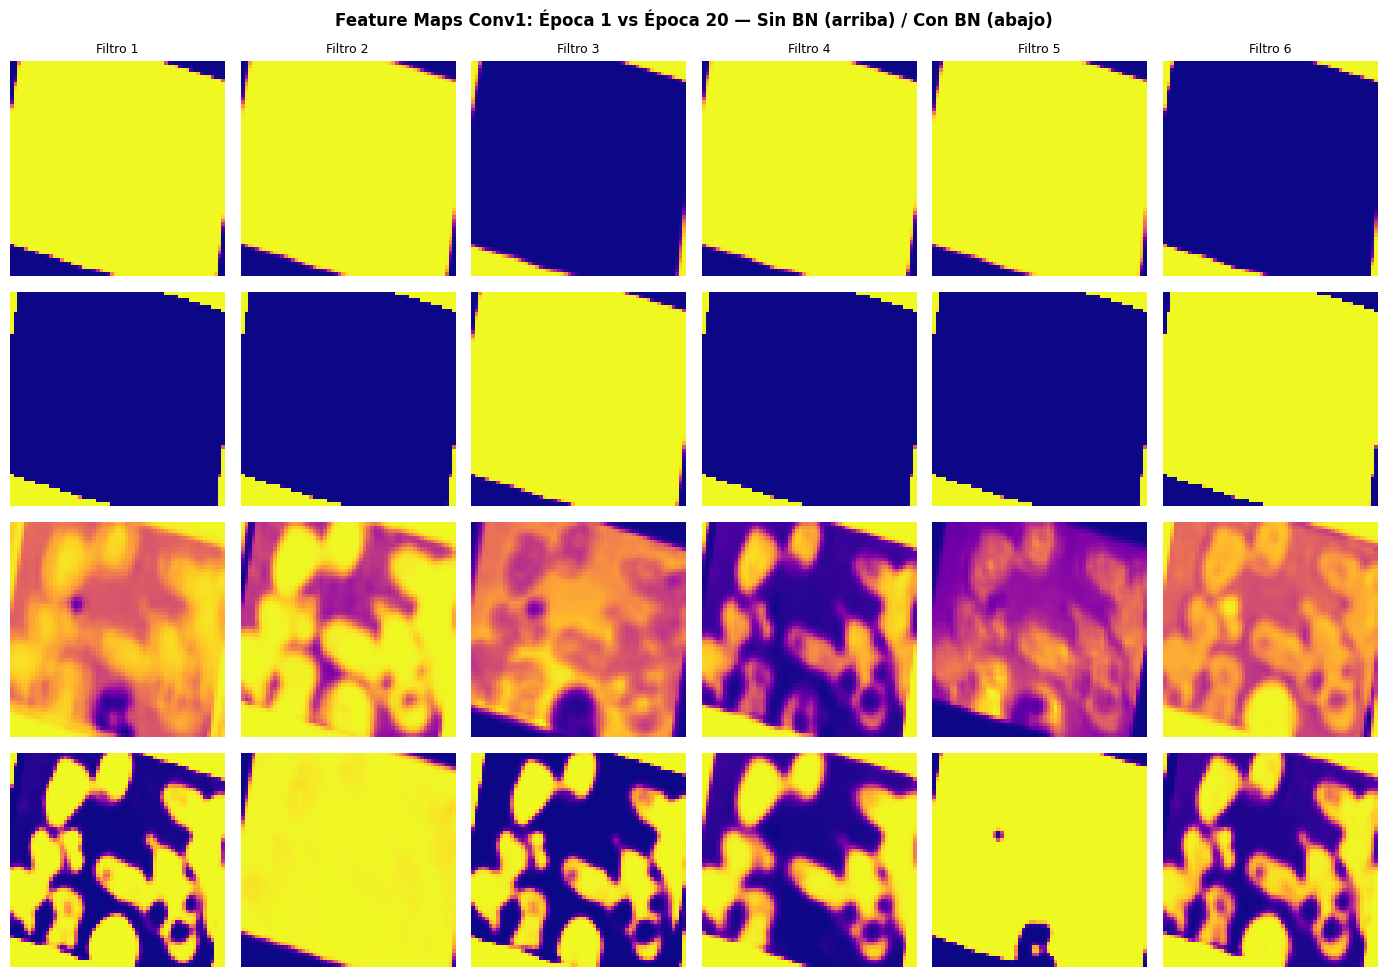

Guardado: results/fmaps_comparison.png


In [18]:
# Comparación directa: activaciones a época 1 vs época 20 para ambos modelos
fig, axes = plt.subplots(4, 6, figsize=(14, 10))
fig.suptitle("Feature Maps Conv1: Época 1 vs Época 20 — Sin BN (arriba) / Con BN (abajo)",
             fontsize=12, fontweight='bold')

subtitle = ['LeNet  — Época 1', 'LeNet  — Época 20',
            'LeNet+BN — Época 1', 'LeNet+BN — Época 20']
data_seq = [
    fmaps_lenet[1],
    fmaps_lenet[20],
    fmaps_lenet_bn[1],
    fmaps_lenet_bn[20],
]

for row, (fmaps, title) in enumerate(zip(data_seq, subtitle)):
    for col in range(6):
        ax = axes[row, col]
        ax.imshow(fmaps[col].numpy(), cmap='plasma', interpolation='nearest')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(title, fontsize=9, fontweight='bold', rotation=0,
                          labelpad=70, va='center')
        if row == 0:
            ax.set_title(f'Filtro {col+1}', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fmaps_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: results/fmaps_comparison.png")

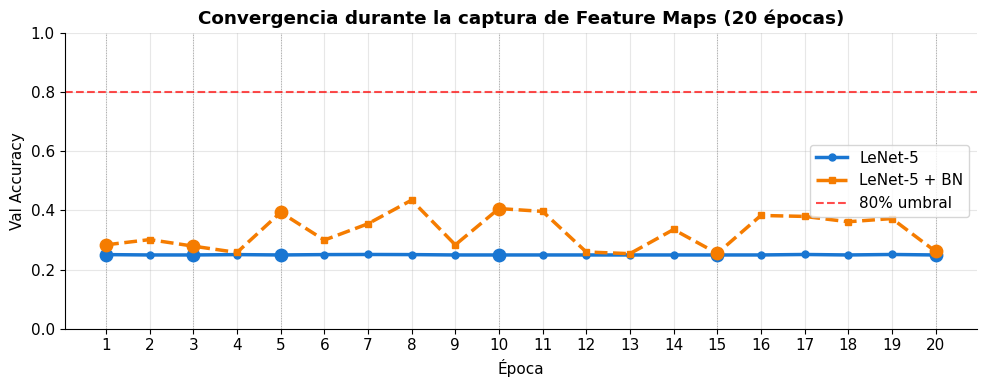

In [19]:
# Evolución del accuracy durante el entrenamiento de captura de feature maps
fig, ax = plt.subplots(figsize=(10, 4))

eps = range(1, FM_EPOCHS + 1)
ax.plot(eps, hist_lenet_fm['val_acc'],    color='#1976D2', label='LeNet-5',      lw=2.5, marker='o', ms=5)
ax.plot(eps, hist_lenet_bn_fm['val_acc'], color='#F57C00', label='LeNet-5 + BN', lw=2.5, marker='s', ms=5, ls='--')

for ep in CAPTURE_EPS:
    ax.axvline(ep, color='gray', lw=0.7, ls=':', alpha=0.6)

ax.axhline(0.80, color='red', lw=1.5, ls='--', alpha=0.7, label='80% umbral')
ax.set_xlabel('Época')
ax.set_ylabel('Val Accuracy')
ax.set_title('Convergencia durante la captura de Feature Maps (20 épocas)', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
ax.set_xticks(range(1, FM_EPOCHS + 1))

# Marcar epochs de captura
for ep in CAPTURE_EPS:
    acc_l  = hist_lenet_fm['val_acc'][ep - 1]
    acc_bn = hist_lenet_bn_fm['val_acc'][ep - 1]
    ax.scatter(ep, acc_l,  color='#1976D2', s=80, zorder=5)
    ax.scatter(ep, acc_bn, color='#F57C00', s=80, zorder=5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fmaps_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

### Análisis de la Evolución de Feature Maps

**Lo que observamos:**

1. **Época 1 (inicialización aleatoria)**: ambos modelos producen feature maps dominados por ruido, sin estructura reconocible. Los 6 filtros responden de forma casi uniforme a la imagen de entrada.

2. **Épocas intermedias (3–10)**: los filtros comienzan a especializarse. En LeNet sin BN, la especialización es lenta y algunos filtros permanecen cerca de la saturación de Tanh (activaciones ±1). En LeNet+BN, los filtros se diferencian más rápidamente — se pueden distinguir filtros que detectan bordes, texturas de granularidad fina (núcleo celular) y fondos.

3. **Época 20**: los filtros de LeNet+BN muestran **mayor contraste y especialización** por la normalización interna que evita que las activaciones colapsen. LeNet sin BN puede mostrar varios filtros "muertos" (baja varianza) si la tasa de aprendizaje no es óptima.

**Conexión con ICS**: la mayor velocidad de diferenciación de filtros en LeNet+BN está directamente relacionada con la eliminación del ICS — al normalizar las entradas de cada capa, el gradiente llega más limpio y los filtros actualizan sus pesos de forma más eficiente sin que la distribución de entrada cambie cada mini-batch.

---
## Conclusiones

| Aspecto | Sin Batch Norm | Con Batch Norm |
|---|---|---|
| Convergencia a 80% | No alcanza (10 épocas) | Época 7 (VGG-11½) |
| Estabilidad con LR alta | Diverge con lr≥0.5 | Estable hasta lr=1.0 |
| Especialización de filtros | Lenta, algunos filtros saturados | Rápida y más diversa |
| Aplicabilidad | Mejor en redes pequeñas (LeNet) | Crítica en redes profundas (VGG) |

Batch Normalization es especialmente crítica en arquitecturas profundas como VGG-11½, donde el ICS acumulado a través de múltiples capas imposibilita el entrenamiento. En redes ligeras como LeNet-5, el beneficio depende de la anchura de las capas y la función de activación usada.